# Acoustic Uroflowmetry Prototype
Estimate urinary flow rate from sound using DSP features and super vised ML models to estimate new measures.




In [ ]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import operator

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from sklearn.ensemble import RandomForestClassifier

import glob
import os

from scipy.signal import butter, lfilter




## Load Calibration and fit/test models

Préparation jeux de données

In [ ]:
# calib = pd.read_csv("calibration_sounds_features.csv", sep=",")
calib = pd.read_csv("clean_calibration_sounds_features.csv", sep=",")

# X = features
X = calib.iloc[:, :-1]
# y = débit (target)
y = calib.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

jeu_test_real = pd.read_csv("sons_tests_features.csv", sep=",")

X_real = jeu_test_real.iloc[:, :-1]
y_real = jeu_test_real.iloc[:, -1]


Instenciation des modèles de ML pour benchmark

In [ ]:
# model KNN regressor
from xml.parsers.expat import model
    
# Modèle supervisé
model_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'   # ou'uniform', 'distance' si tu veux pondérer par proximité
    )
    
train_KNN = KNeighborsRegressor(
        n_neighbors=3,
        metric='euclidean',
        weights='distance'
    )
model_KNN.fit(X, y) # entrainemet du modèle sur tout le dataset de calibration pour certaines analyses
train_KNN.fit(X_train, y_train)

# Random Forest
from sklearn.ensemble import RandomForestRegressor

    # entrainement tout le set de données
model_rf = RandomForestRegressor(random_state=42)
train_rf = RandomForestRegressor(random_state=42)

model_rf.fit(X, y)
train_rf.fit(X_train, y_train)


from sklearn.preprocessing import StandardScaler
import numpy as np

# Scaling (très important pour Lasso et Ridge)
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)
X_test_real_scaled = scaler.transform(X_real)

# Model Lasso
from sklearn.linear_model import Lasso

# Entraînement du modèle
model_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)
train_lasso = Lasso(alpha=0.01, max_iter=10000, random_state=42)

model_lasso.fit(X_all_scaled, y)
train_lasso.fit(X_train_scaled, y_train)

# Model RIDGE

from sklearn.linear_model import Ridge


# Entraînement du modèle
model_ridge = Ridge(random_state=42)
train_ridge = Ridge(random_state=42)

model_ridge.fit(X_all_scaled, y)
train_ridge.fit(X_train_scaled, y_train)


Ridge(random_state=42)

# KNN

0.9371890278842909


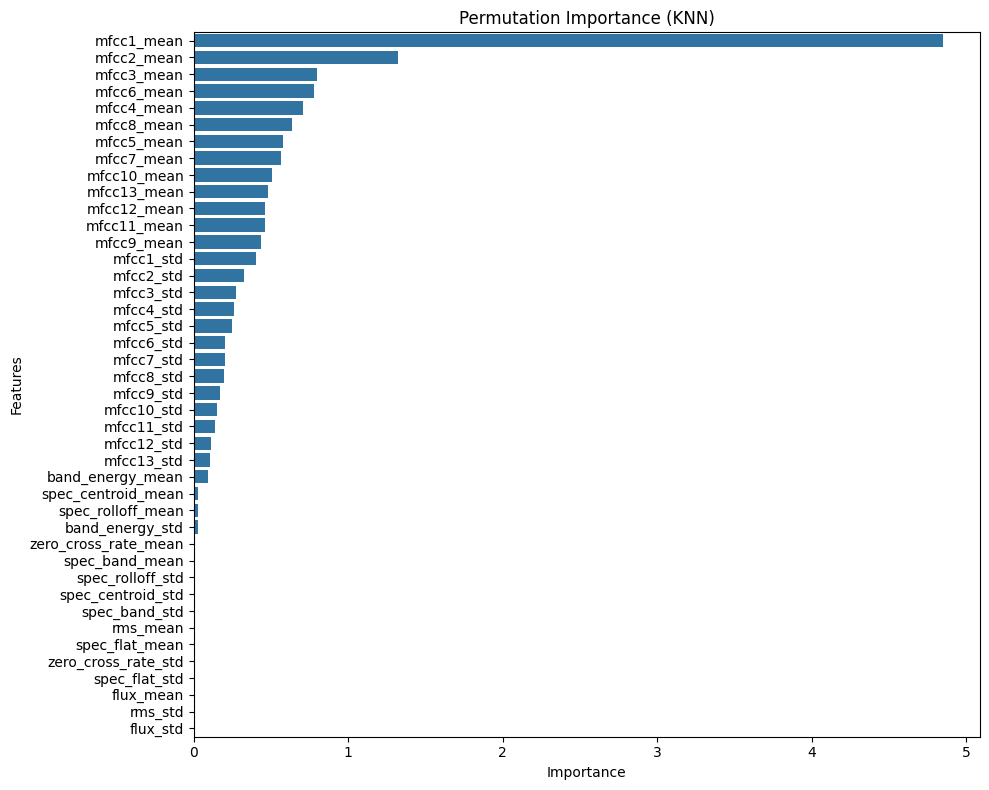

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

'''Principe :

On mesure la performance du modèle

On mélange une feature

On regarde combien la performance chute

Si elle chute beaucoup → feature importante.'''


# Permutation importance
result = permutation_importance(
    model_KNN,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_KNN.score(X_test, y_test))

plt.title("Permutation Importance (KNN)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# Bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# Variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Couleurs personnalisées (contrastées)
color_map = {
    "0-4mls": "blue",
    "4-8mls": "green",
    "8-12mls": "red",
    "12-16mls": "black",
    "16-20mls": "orange"   # 5e classe (si tu veux on peut aussi la garder rouge foncé)
}

# Scatter interactif
fig = px.scatter(
    df,
    x="spec_rolloff_std",
    y="spec_rolloff_mean",
    color="debit_range",
    color_discrete_map=color_map,
    hover_data={
        "debit": True,
        "mfcc12_mean": True,
        "mfcc9_mean": True
    },
    title="Scatter plot spec_rolloff_std vs spec_rolloff_mean par plage de débit"
)

fig.show()


In [ ]:
# KNN Regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_KNN.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_KNN.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_KNN.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   10.586   9.528479  1.057521
1    7.340   7.703431  0.363431
2   13.003  11.711541  1.291459
3   25.000  19.616060  5.383940
4    0.000   0.637931  0.637931
5    8.753   9.415950  0.662950
6   10.504  11.484970  0.980970
7   15.105  16.222133  1.117133
8    4.540   4.041006  0.498994
9   10.949  12.096752  1.147752
10  21.929  20.238499  1.690501
11   9.990   9.326760  0.663240
12  16.051  16.548841  0.497841
13  14.285  15.500139  1.215139
14   5.000   4.447516  0.552484
15   0.030   0.013262  0.016738
16   6.250   7.333000  1.083000
17   8.820   9.016809  0.196809
18  11.188   9.445839  1.742161
MAE: 1.09
tableaux de comparaison des données de mesures réelles
   y_real     y_pred    erreur
0   8.930  11.995533  3.065533
1   9.290   1.243171  8.046829
2  10.090  12.302363  2.212363
3  11.049  14.117718  3.068718
4  11.120   1.244476  9.875524
5  11.760  14.114940  2.354940
6  12.500  15.557411 

# Random Forest

0.9122019151815378


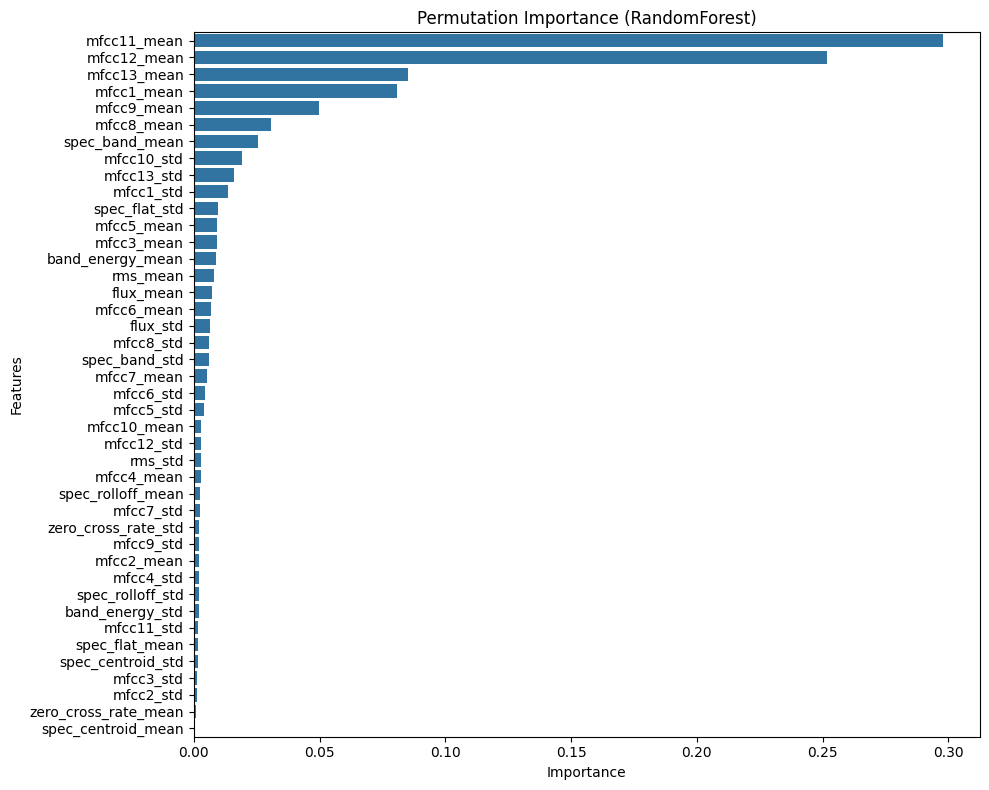

In [ ]:
# Random Forest

# model_rf, train_rf = load_rf_model()

importances = model_rf.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_rf.score(X_test, y_test))

plt.title("Permutation Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [ ]:
# Random forest regressor
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_rf.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_rf.predict(X_real) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test    y_pred   erreur
0   10.586   9.65475  0.93125
1    7.340   7.32519  0.01481
2   13.003  12.75495  0.24805
3   25.000  19.20635  5.79365
4    0.000   0.88000  0.88000
5    8.753  10.54635  1.79335
6   10.504  11.48459  0.98059
7   15.105  17.75442  2.64942
8    4.540   4.26515  0.27485
9   10.949  10.58418  0.36482
10  21.929  20.29739  1.63161
11   9.990  10.12498  0.13498
12  16.051  16.36677  0.31577
13  14.285  17.38068  3.09568
14   5.000   4.56308  0.43692
15   0.030   1.08277  1.05277
16   6.250   7.42928  1.17928
17   8.820   8.78567  0.03433
18  11.188   9.54091  1.64709
MAE: 1.23
tableaux de comparaison des données de mesures réelles
   y_real    y_pred   erreur
0   8.930  12.65513  3.72513
1   9.290   8.17477  1.11523
2  10.090  14.82052  4.73052
3  11.049  15.49278  4.44378
4  11.120   8.16158  2.95842
5  11.760   9.26513  2.49487
6  12.500  16.41455  3.91455
7  15.331  11.55662  3.77438
8  18.650  19.884

# Ridge Regression

R2 test : 0.8204807493376175


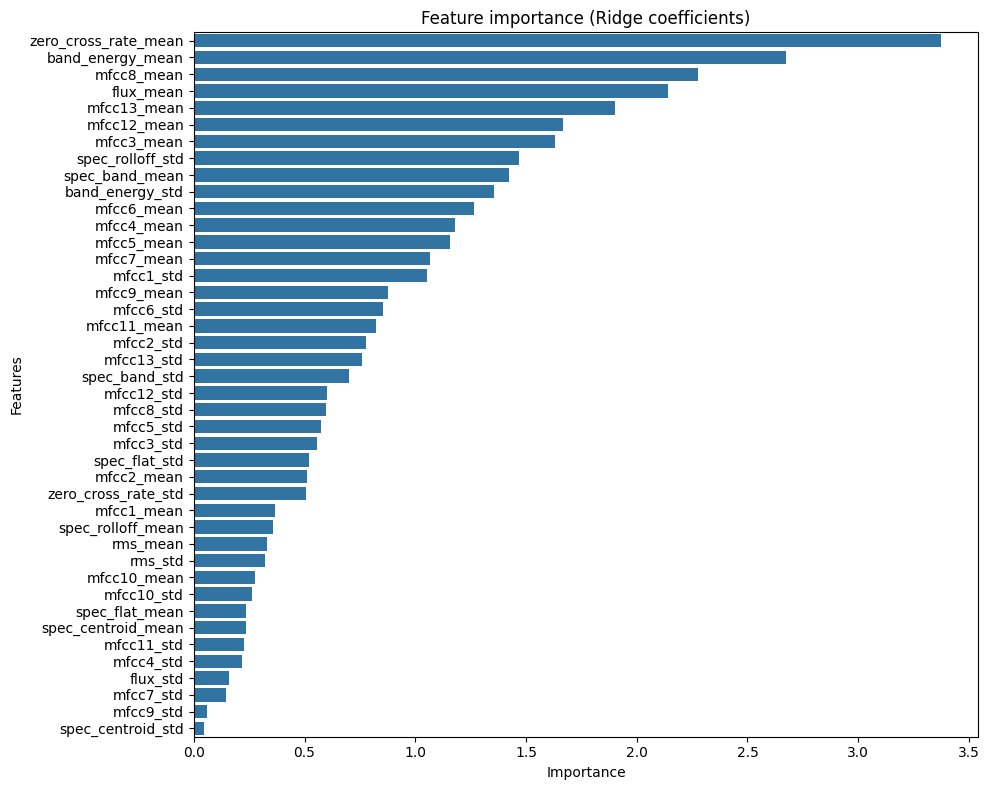

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns


# Importance = valeur absolue des coefficients
importances = np.abs(model_ridge.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = train_ridge.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Ridge coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [ ]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_ridge.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_ridge.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   10.586   9.903281  0.682719
1    7.340   7.497496  0.157496
2   13.003  14.057230  1.054230
3   25.000  17.861937  7.138063
4    0.000   2.522612  2.522612
5    8.753  11.781184  3.028184
6   10.504  10.310746  0.193254
7   15.105  16.410097  1.305097
8    4.540   4.170894  0.369106
9   10.949  11.985851  1.036851
10  21.929  21.126166  0.802834
11   9.990   9.360741  0.629259
12  16.051  17.425438  1.374438
13  14.285  17.794414  3.509414
14   5.000   5.438390  0.438390
15   0.030   5.503729  5.473729
16   6.250   4.574576  1.675424
17   8.820  10.593831  1.773831
18  11.188   8.126551  3.061449
MAE: 1.91
tableaux de comparaison des données de mesures réelles
   y_real     y_pred     erreur
0   8.930  12.066040   3.136040
1   9.290   1.318353   7.971647
2  10.090  13.405523   3.315523
3  11.049  10.153823   0.895177
4  11.120   1.095836  10.024164
5  11.760   9.270794   2.489206
6  12.500  13.

# Lasso Regression

R2 test : 0.9416418759501143


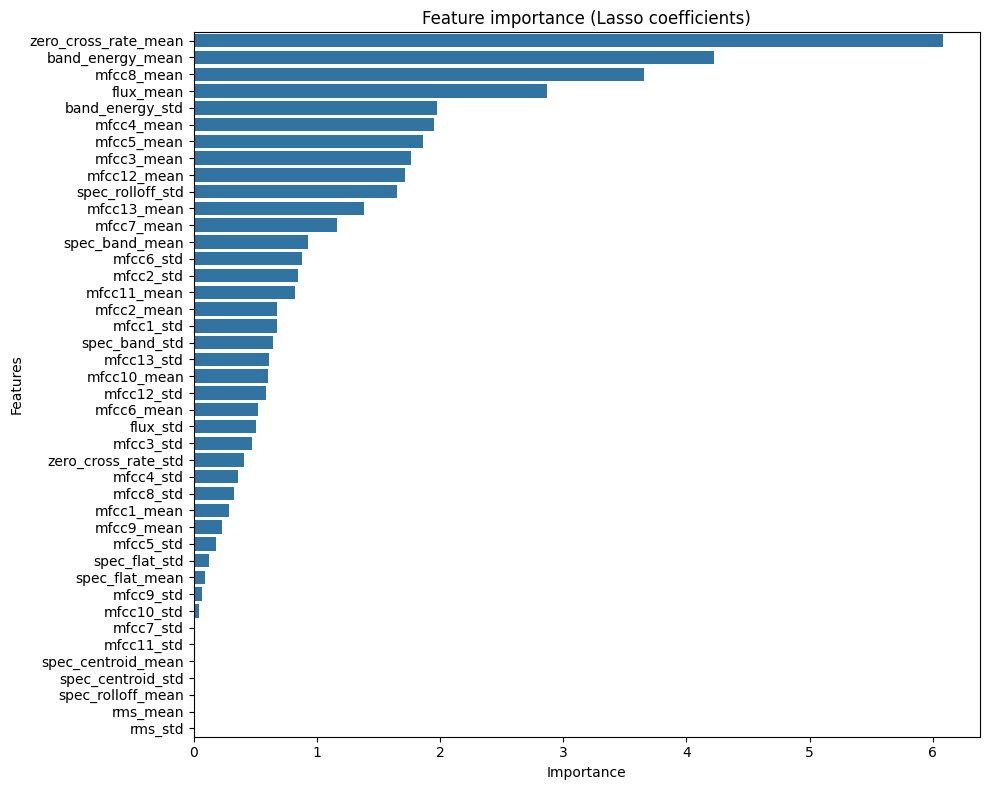

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns



# Importance = valeur absolue des coefficients
importances = np.abs(model_lasso.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = model_lasso.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Lasso coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Features sélectionnées par Lasso
selected_features = calib.columns[:-1][model_lasso.coef_ != 0]
# print("Features retenues par Lasso :")
# print(selected_features)


In [ ]:
# Ridge
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = train_lasso.predict(X_test_scaled)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print("tableaux de comparaison des données de test échnantillon")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

y_pred_real = model_lasso.predict(X_test_real_scaled) # on prend le modèle entrainé sur tout le dataset de calibration pour les prédictions réelles
# y_pred_real = train_rf.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_real": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_real"] - comparaison["y_pred"])

print("tableaux de comparaison des données de mesures réelles")
print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

tableaux de comparaison des données de test échnantillon
    y_test     y_pred    erreur
0   10.586  10.737002  0.151002
1    7.340   7.240686  0.099314
2   13.003  11.926226  1.076774
3   25.000  17.687005  7.312995
4    0.000   2.949428  2.949428
5    8.753  11.065057  2.312057
6   10.504   9.781372  0.722628
7   15.105  16.206094  1.101094
8    4.540   5.040492  0.500492
9   10.949  11.459659  0.510659
10  21.929  21.451739  0.477261
11   9.990   8.783953  1.206047
12  16.051  17.893302  1.842302
13  14.285  18.761582  4.476582
14   5.000   5.571854  0.571854
15   0.030   7.901683  7.871683
16   6.250   4.379795  1.870205
17   8.820  10.489614  1.669614
18  11.188   8.044736  3.143264
MAE: 2.1
tableaux de comparaison des données de mesures réelles
   y_real     y_pred     erreur
0   8.930  11.994641   3.064641
1   9.290   5.737062   3.552938
2  10.090  13.193045   3.103045
3  11.049  10.610756   0.438244
4  11.120   5.619489   5.500511
5  11.760  10.293742   1.466258
6  12.500  13.1

Rappel : qu’est-ce que mfcc7_mean ?

Les MFCC (Mel-Frequency Cepstral Coefficients) décrivent :

la forme du spectre

la structure fréquentielle globale

le “timbre” du signal

mfcc7_mean = moyenne temporelle du 7ᵉ coefficient.

👉 Donc c’est une information spectrale compressée.

Si le débit influence :

    la pression

    la turbulence

    le bruit généré

    la répartition énergétique dans le spectre

Alors il est plausible qu’un MFCC soit corrélé au débit.

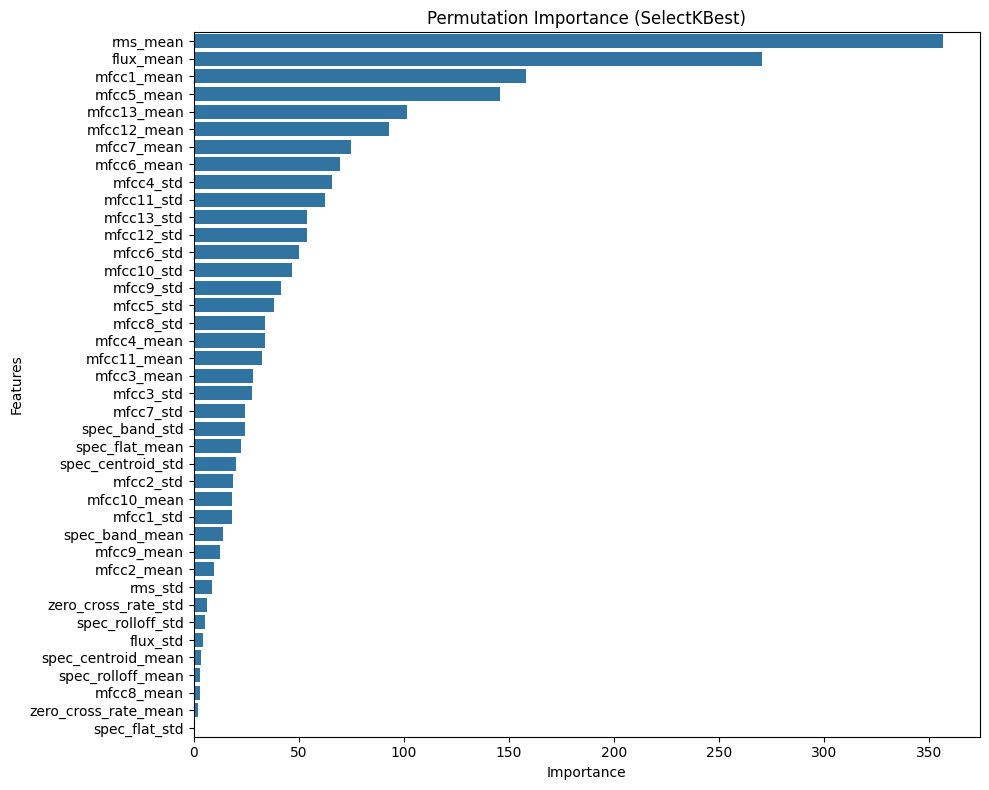

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

# mesure corrélation linéaire uniquement!!

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)


importances = selector.scores_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Permutation Importance (SelectKBest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Estimate Flow for a Segment

In [ ]:
def estimate_flow(feat, model):
    """
    feat : vecteur features 1D (35 features par ex.)
    model : modèle KNeighborsRegressor déjà entraîné
    """
    
    feat = np.array(feat).reshape(1, -1)  # nécessaire pour sklearn
    prediction = model.predict(feat)

    return prediction[0]


## Analyze a Real Recording

In [ ]:
def analyze_recording(file_path, nn, y_calib):
    y, sr = librosa.load(file_path, sr=32000)
    segments, frame_len = segment_audio(y, sr)

    results = []

    for i, (s, e) in enumerate(segments):
        seg = y[s*frame_len:e*frame_len]
        feat = extract_features(seg, sr)
        debit = estimate_flow(feat, nn, y_calib)
        duration = (e - s) * 0.2
        results.append({"phase": i+1, "debit": debit, "duree": duration})

    return results


## Plot Uroflow Curve

In [ ]:
def plot_uroflow(results):
    times = []
    flows = []
    t = 0

    for r in results:
        times.append(t)
        flows.append(r['debit'])
        t += r['duree']

    plt.step(times, flows)
    plt.xlabel('Time (s)')
    plt.ylabel('Flow (ml/s)')
    plt.title('Estimated Uroflow Curve')
    plt.show()
